In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

os.chdir(r'C:\Users\KIIT0001\sepsis-detection')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

data = pd.read_parquet('data/processed/clean.parquet')

sepsis_pts = data[data.groupby('patient_id')['SepsisLabel'].transform('max') == 1]
normal_pts = data[data.groupby('patient_id')['SepsisLabel'].transform('max') == 0]

print(f"Sepsis patients:  {sepsis_pts['patient_id'].nunique():,}")
print(f"Normal patients:  {normal_pts['patient_id'].nunique():,}")
print(f"Total rows: {len(data):,}")

Sepsis patients:  2,932
Normal patients:  37,404
Total rows: 1,552,210


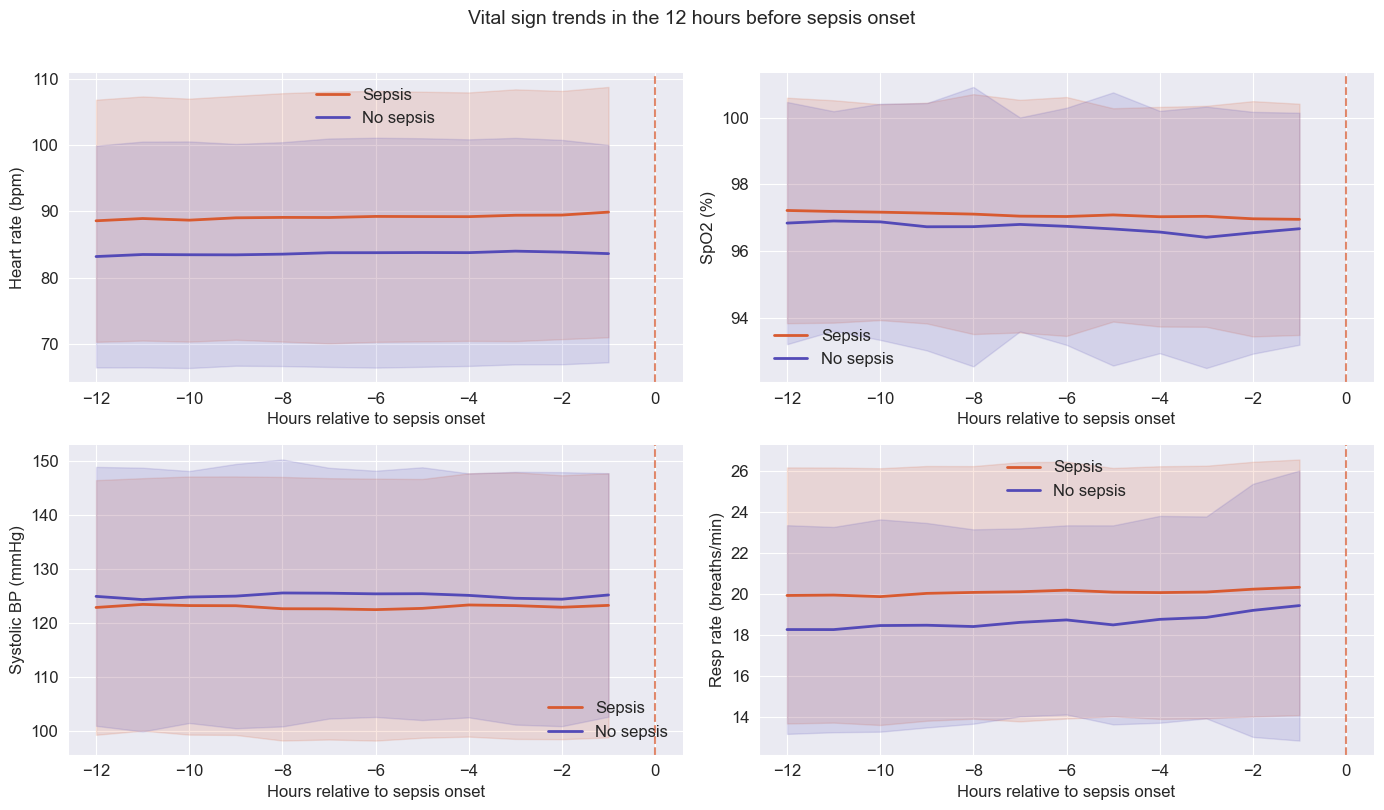

Saved plot1_vital_trends.png


In [2]:
def get_pre_onset_windows(df, hours_before=12):
    windows = []
    for pid, group in df.groupby('patient_id'):
        onset = group[group['SepsisLabel'] == 1]
        if len(onset) == 0:
            continue
        onset_hour = onset['ICULOS'].min()
        pre = group[group['ICULOS'] < onset_hour].tail(hours_before)
        if len(pre) >= hours_before // 2:
            pre = pre.copy()
            pre['hours_to_onset'] = pre['ICULOS'] - onset_hour
            windows.append(pre)
    return pd.concat(windows, ignore_index=True) if windows else pd.DataFrame()

def get_random_windows(df, hours=12, n_patients=500):
    windows = []
    patients = df['patient_id'].unique()
    np.random.seed(42)
    sampled = np.random.choice(patients, min(n_patients, len(patients)), replace=False)
    for pid in sampled:
        group = df[df['patient_id'] == pid]
        if len(group) >= hours:
            tail = group.tail(hours).copy()
            tail['hours_to_onset'] = range(-len(tail), 0)
            windows.append(tail)
    return pd.concat(windows, ignore_index=True) if windows else pd.DataFrame()

pre_onset = get_pre_onset_windows(sepsis_pts, hours_before=12)
normal_windows = get_random_windows(normal_pts, hours=12)

vitals = [('HR', 'Heart rate (bpm)'),
          ('O2Sat', 'SpO2 (%)'),
          ('SBP', 'Systolic BP (mmHg)'),
          ('Resp', 'Resp rate (breaths/min)')]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(vitals):
    ax = axes[i]
    if col not in pre_onset.columns:
        continue
    sep_mean = pre_onset.groupby('hours_to_onset')[col].mean()
    nor_mean = normal_windows.groupby('hours_to_onset')[col].mean()
    sep_std  = pre_onset.groupby('hours_to_onset')[col].std()
    nor_std  = normal_windows.groupby('hours_to_onset')[col].std()

    ax.plot(sep_mean.index, sep_mean.values, color='#D85A30', lw=2, label='Sepsis')
    ax.fill_between(sep_mean.index,
                    sep_mean - sep_std, sep_mean + sep_std,
                    color='#D85A30', alpha=0.15)
    ax.plot(nor_mean.index, nor_mean.values, color='#534AB7', lw=2, label='No sepsis')
    ax.fill_between(nor_mean.index,
                    nor_mean - nor_std, nor_mean + nor_std,
                    color='#534AB7', alpha=0.15)
    ax.axvline(0, color='#D85A30', linestyle='--', lw=1.5, alpha=0.7)
    ax.set_xlabel('Hours relative to sepsis onset')
    ax.set_ylabel(label)
    ax.legend(frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Vital sign trends in the 12 hours before sepsis onset', fontsize=14, fontweight='normal', y=1.01)
plt.tight_layout()
plt.savefig('notebooks/plot1_vital_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot1_vital_trends.png")

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_4828\2232752674.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([nor_vals, sep_vals],
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_4828\2232752674.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([nor_vals, sep_vals],
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_4828\2232752674.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([nor_vals, sep_vals],
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_4828\2232752674.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labe

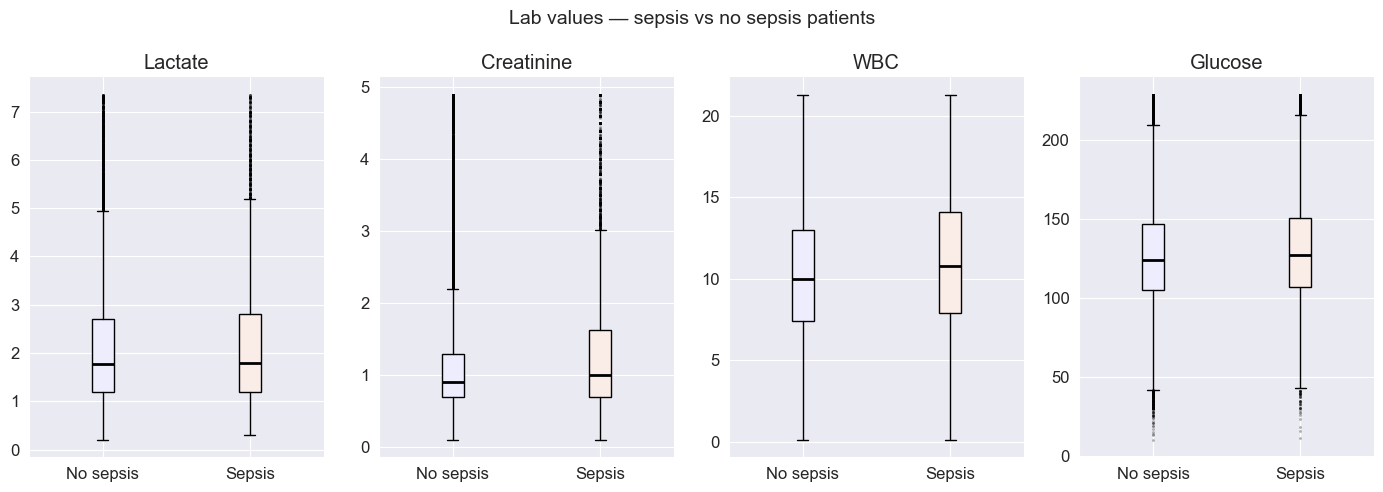

Saved plot2_lab_distributions.png


In [3]:
labs = ['Lactate', 'Creatinine', 'WBC', 'Glucose']
available_labs = [l for l in labs if l in data.columns]

fig, axes = plt.subplots(1, len(available_labs), figsize=(14, 5))

for i, lab in enumerate(available_labs):
    ax = axes[i]
    sep_vals = sepsis_pts[lab].dropna()
    nor_vals = normal_pts[lab].dropna()

    p95 = np.percentile(pd.concat([sep_vals, nor_vals]), 95)
    sep_vals = sep_vals[sep_vals <= p95]
    nor_vals = nor_vals[nor_vals <= p95]

    bp = ax.boxplot([nor_vals, sep_vals],
                    labels=['No sepsis', 'Sepsis'],
                    patch_artist=True,
                    medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(lw=1),
                    capprops=dict(lw=1),
                    flierprops=dict(marker='.', ms=2, alpha=0.3))

    bp['boxes'][0].set_facecolor('#EEEDFE')
    bp['boxes'][1].set_facecolor('#FAECE7')

    ax.set_title(lab, fontweight='normal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Lab values — sepsis vs no sepsis patients', fontsize=14, fontweight='normal')
plt.tight_layout()
plt.savefig('notebooks/plot2_lab_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot2_lab_distributions.png")

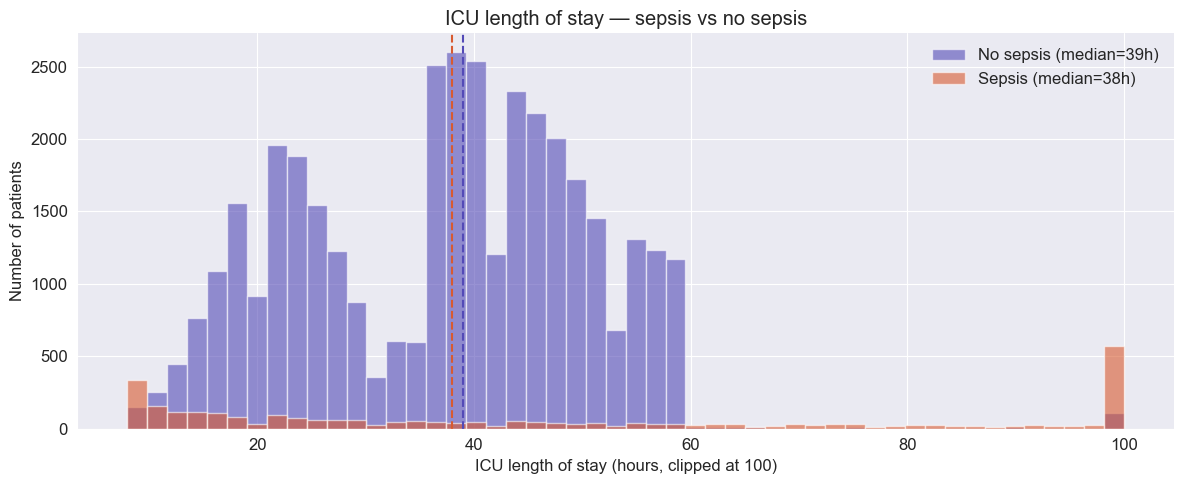

In [4]:
sep_stay   = sepsis_pts.groupby('patient_id')['ICULOS'].max()
nor_stay   = normal_pts.groupby('patient_id')['ICULOS'].max()

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(nor_stay.clip(upper=100), bins=50, alpha=0.6,
        color='#534AB7', label=f'No sepsis (median={nor_stay.median():.0f}h)')
ax.hist(sep_stay.clip(upper=100), bins=50, alpha=0.6,
        color='#D85A30', label=f'Sepsis (median={sep_stay.median():.0f}h)')

ax.axvline(nor_stay.median(), color='#534AB7', linestyle='--', lw=1.5)
ax.axvline(sep_stay.median(), color='#D85A30', linestyle='--', lw=1.5)
ax.set_xlabel('ICU length of stay (hours, clipped at 100)')
ax.set_ylabel('Number of patients')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('ICU length of stay — sepsis vs no sepsis', fontweight='normal')
plt.tight_layout()
plt.savefig('notebooks/plot3_icu_stay.png', dpi=150, bbox_inches='tight')
plt.show()

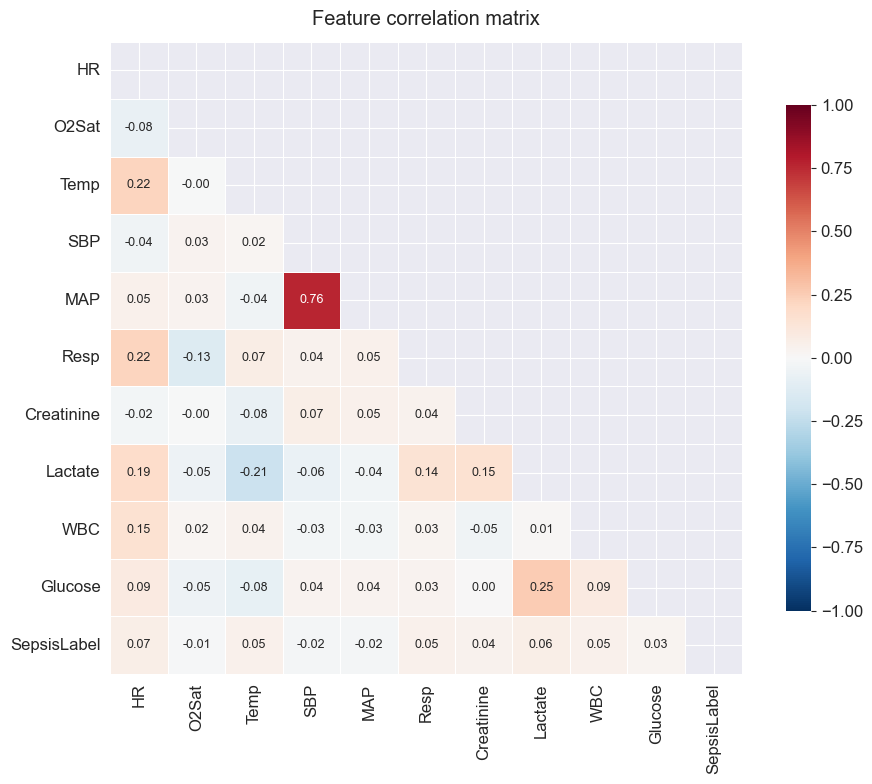

Saved plot4_correlation.png


In [5]:
feat_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'Resp',
             'Creatinine', 'Lactate', 'WBC', 'Glucose', 'SepsisLabel']
feat_cols = [c for c in feat_cols if c in data.columns]

sample = data[feat_cols].dropna(thresh=5).sample(min(50000, len(data)), random_state=42)
corr = sample.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, ax=ax,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature correlation matrix', fontweight='normal', pad=12)
plt.tight_layout()
plt.savefig('notebooks/plot4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot4_correlation.png")

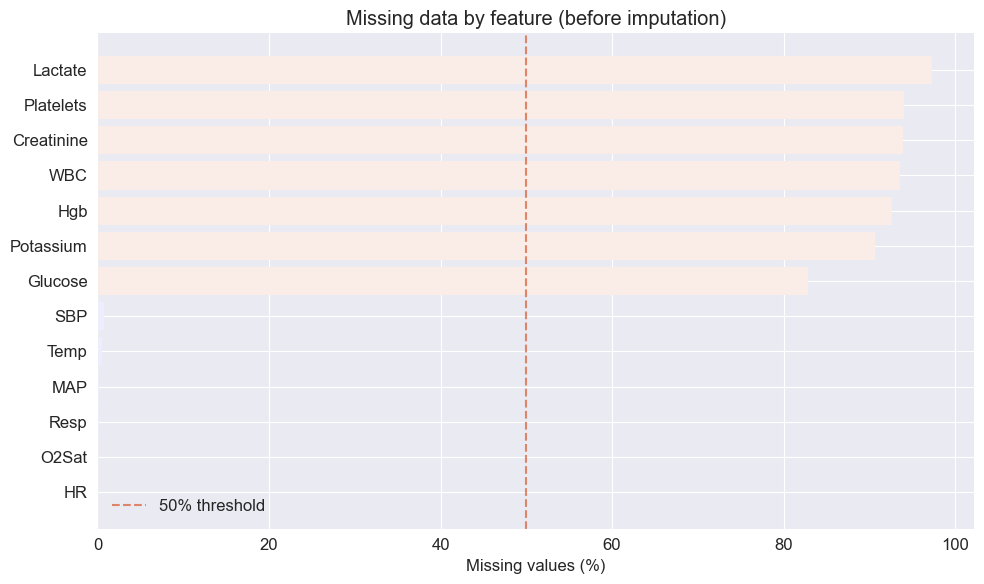

Saved plot5_missing_data.png


In [6]:
feat_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'Resp',
             'Lactate', 'Creatinine', 'WBC', 'Glucose',
             'Potassium', 'Hgb', 'Platelets']
feat_cols = [c for c in feat_cols if c in data.columns]

missing_pct = data[feat_cols].isnull().mean() * 100
missing_pct = missing_pct.sort_values(ascending=True)

colors = ['#FAECE7' if v > 50 else '#EEEDFE' for v in missing_pct.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='none')
ax.axvline(50, color='#D85A30', linestyle='--', lw=1.5, alpha=0.7, label='50% threshold')
ax.set_xlabel('Missing values (%)')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title('Missing data by feature (before imputation)', fontweight='normal')
plt.tight_layout()
plt.savefig('notebooks/plot5_missing_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot5_missing_data.png")